In [114]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx



**Imports.** Loads the core libraries used throughout the notebook: `pandas` for data handling, `seaborn`/`matplotlib` for plotting, and `networkx` for the cross-sell network graph later on.

In [115]:
df = pd.read_csv(
    "../eabl parsed csv/sales_products_merged_cleaned.csv",
    usecols=['customer_code', 'visit_date', 'segment_grouped', 'Brand', 'quantity'],
    low_memory=False
)



**Load the raw sales data.** Reads `sales_products_merged_cleaned.csv`, pulling only the 5 columns needed for basket analysis: which outlet (`customer_code`), when (`visit_date`), what type of outlet (`segment_grouped`), what was bought (`Brand`), and how much (`quantity`).

In [116]:
df

,customer_code,visit_date,quantity,segment_grouped,Brand
0,KE0062192,2026-01-08,7.00,Bar,Returnable
1,KE0062192,2026-01-08,0.28,Bar,Tusker Lager
2,KE0062192,2026-01-08,1.00,Bar,Kenya Cane
3,KE0062192,2026-01-08,2.00,Bar,Smirnoff Vodka Red
4,KE0062192,2026-01-08,0.60,Bar,Guinness
...,...,...,...,...,...
984287,KE0170375,2026-06-27,0.32,Specialist Store,Smirnoff Ice Raspberry twist
984288,KE0187045,2026-06-17,0.60,Bar,Smirnoff Ice Raspberry twist
984289,KE0071094,2026-06-30,1.00,Specialist Store,Smirnoff Ice Raspberry twist
984290,KE0167300,2026-06-20,0.48,Other,Smirnoff Ice Raspberry twist


**Preview the raw data.** Displays the loaded dataframe as-is, before any cleaning, to confirm it loaded correctly and to see the raw shape and columns.

In [117]:
df[['segment_grouped']].nunique()

segment_grouped    7
dtype: int64

**Check segment count.** Confirms there are 7 distinct outlet types in `segment_grouped` — this is the number of separate analyses that will be run, one per segment, never mixed together.

In [118]:
df['visit_date'] = pd.to_datetime(df['visit_date'])

# Only real purchases — return_quantity is a separate column, this is the line-level ordered qty
df = df[df['quantity'] > 0]

# "Returnable" is a placeholder for empty bottle/crate deposits, not a real brand —
# it's 15.5% of all rows and would flood every basket with a meaningless "co-occurrence"
df = df[df['Brand'] != 'Returnable']

df = df.dropna(subset=['customer_code', 'visit_date', 'segment_grouped', 'Brand'])
df['Brand'] = df['Brand'].str.strip()

df['basket_id'] = df['customer_code'].astype(str) + "_" + df['visit_date'].astype(str)

print(df.groupby('segment_grouped')['basket_id'].nunique().sort_values(ascending=False))

segment_grouped
Bar                 54478
Specialist Store    35814
Other                2385
Wholesaler           1670
Lodging              1552
Event                 729
Nightclub             644
Name: basket_id, dtype: int64


**Core cleaning and basket construction.** Converts `visit_date` to a real date type, keeps only rows with an actual purchase (`quantity > 0`), removes the `Returnable` placeholder (empty bottle/crate deposits — not a real brand), drops rows missing key fields, standardizes brand name spacing, and builds `basket_id` (customer + visit date) — the unit that defines "one basket" for the rest of the analysis. The printed counts show how many baskets exist per segment.

In [119]:
before = len(df)
df = df.drop_duplicates(subset=['customer_code', 'visit_date', 'Brand', 'quantity'])
print(f"Dropped {before - len(df)} duplicate rows")

Dropped 45151 duplicate rows


**Remove duplicate rows.** Drops rows that are identical on customer, date, brand, and quantity — these don't add any new information to a basket and would otherwise inflate counts.

In [120]:
import difflib
brands = sorted(df['Brand'].unique())
for i, b in enumerate(brands):
    close = difflib.get_close_matches(b, brands[i+1:], n=1, cutoff=0.9)
    if close:
        print(f"Possible near-duplicate: '{b}' vs '{close[0]}'")
print(f"Distinct brands after cleaning: {df['Brand'].nunique()}")

Distinct brands after cleaning: 83


**Sanity-check brand names.** Scans for brand strings that are nearly identical (e.g. differing only by spacing or a small typo) that might have slipped through cleaning as separate brands. Also prints the final distinct brand count (83) used for the rest of the analysis.

In [121]:
df

,customer_code,visit_date,quantity,segment_grouped,Brand,basket_id
1,KE0062192,2026-01-08,0.28,Bar,Tusker Lager,KE0062192_2026-01-08
2,KE0062192,2026-01-08,1.00,Bar,Kenya Cane,KE0062192_2026-01-08
3,KE0062192,2026-01-08,2.00,Bar,Smirnoff Vodka Red,KE0062192_2026-01-08
4,KE0062192,2026-01-08,0.60,Bar,Guinness,KE0062192_2026-01-08
5,KE0062192,2026-01-08,0.25,Bar,Tusker Lite,KE0062192_2026-01-08
...,...,...,...,...,...,...
984287,KE0170375,2026-06-27,0.32,Specialist Store,Smirnoff Ice Raspberry twist,KE0170375_2026-06-27
984288,KE0187045,2026-06-17,0.60,Bar,Smirnoff Ice Raspberry twist,KE0187045_2026-06-17
984289,KE0071094,2026-06-30,1.00,Specialist Store,Smirnoff Ice Raspberry twist,KE0071094_2026-06-30
984290,KE0167300,2026-06-20,0.48,Other,Smirnoff Ice Raspberry twist,KE0167300_2026-06-20


**Preview the cleaned data.** Shows the dataframe after cleaning and `basket_id` creation, to confirm the transformations applied correctly before building the basket matrices.

In [122]:
def build_basket_matrix(segment_df):
    matrix = (
        segment_df.groupby(['basket_id', 'Brand'])['quantity']
        .sum()
        .unstack(fill_value=0)
    )
    return matrix.gt(0)  # True/False presence, not raw quantities

segments = df['segment_grouped'].unique()
basket_matrices = {seg: build_basket_matrix(df[df['segment_grouped'] == seg]) for seg in segments}

for seg, m in basket_matrices.items():
    print(f"{seg}: {m.shape[0]} baskets, {m.shape[1]} brands")


Bar: 54478 baskets, 77 brands
Specialist Store: 35814 baskets, 80 brands
Wholesaler: 1670 baskets, 78 brands
Other: 2385 baskets, 78 brands
Lodging: 1552 baskets, 77 brands
Event: 729 baskets, 72 brands
Nightclub: 644 baskets, 63 brands


**Build the basket × brand presence matrix, per segment.** Defines `build_basket_matrix`, which reshapes each segment's rows into a table of baskets (rows) × brands (columns) with True/False values — the direct input format `apriori`/`fpgrowth` need. Runs it once per segment and prints how many baskets and brands each segment ended up with.

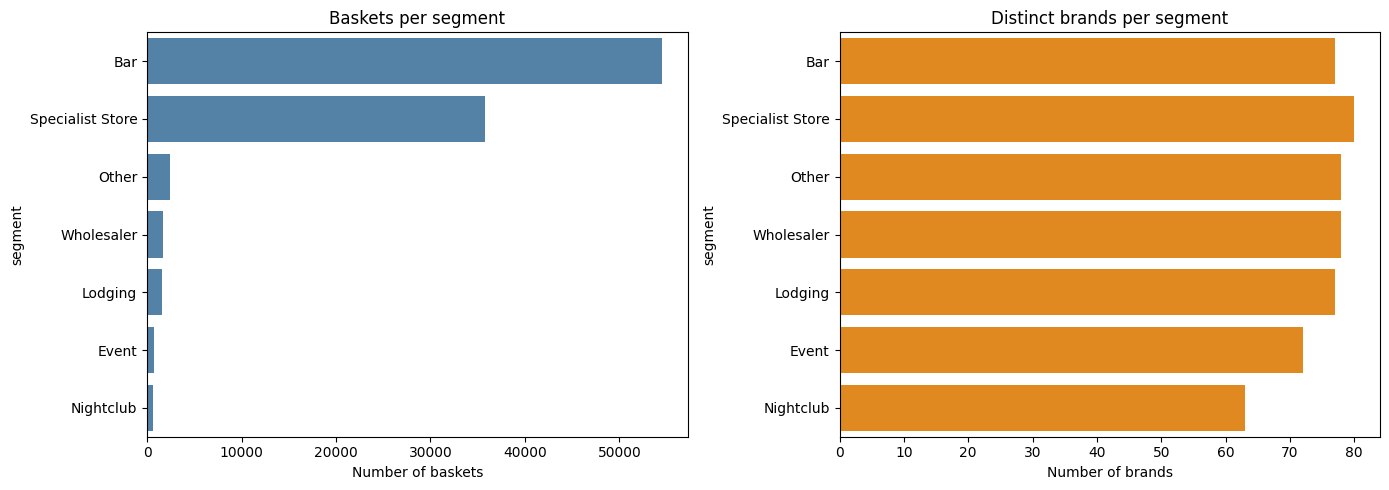

In [123]:


# ── 1. Summary bar chart — baskets vs brands per segment ──
summary = pd.DataFrame({
    'segment': list(basket_matrices.keys()),
    'baskets': [m.shape[0] for m in basket_matrices.values()],
    'brands': [m.shape[1] for m in basket_matrices.values()],
}).sort_values('baskets', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=summary, x='baskets', y='segment', ax=axes[0], color='steelblue')
axes[0].set_title('Baskets per segment')
axes[0].set_xlabel('Number of baskets')

sns.barplot(data=summary, x='brands', y='segment', ax=axes[1], color='darkorange')
axes[1].set_title('Distinct brands per segment')
axes[1].set_xlabel('Number of brands')
plt.tight_layout()
plt.show()




**Visualize basket/brand counts per segment.** A simple bar chart comparing how many baskets and how many distinct brands each segment has — a quick visual read of which segments have enough data to trust (Bar/Specialist Store) versus which are thin (Nightclub/Event).

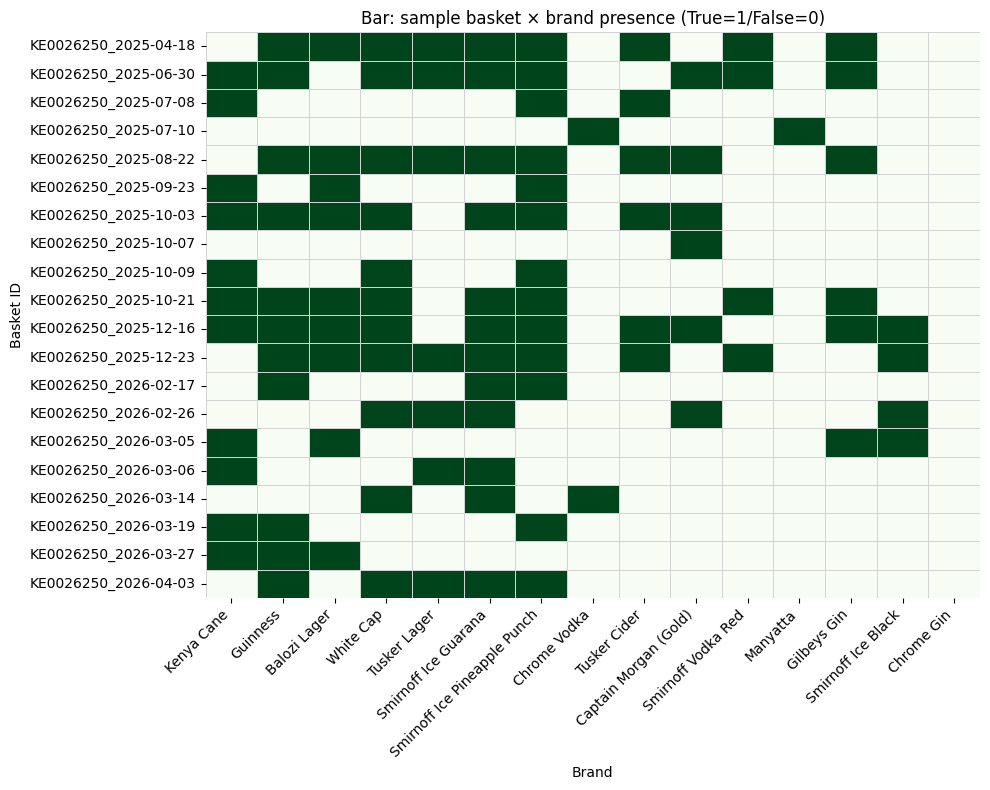

In [124]:
# ── 2. Zoomed-in sample of the actual True/False matrix ──
# Full matrix is too sparse/large to plot — show a readable slice:
# top 20 baskets × top 15 most-frequently-bought brands, for one segment
def plot_matrix_sample(matrix, seg_name, n_baskets=20, n_brands=15):
    top_brands = matrix.sum().sort_values(ascending=False).head(n_brands).index
    sample = matrix.loc[matrix.index[:n_baskets], top_brands]

    plt.figure(figsize=(10, 8))
    sns.heatmap(sample.astype(int), cmap='Greens', cbar=False,
                linewidths=0.5, linecolor='lightgray')
    plt.title(f'{seg_name}: sample basket × brand presence (True=1/False=0)')
    plt.xlabel('Brand')
    plt.ylabel('Basket ID')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_matrix_sample(basket_matrices['Bar'], 'Bar')





**Visualize a readable slice of the basket matrix.** The full True/False matrix is too large and sparse to plot directly, so this shows a small sample — the top 20 baskets and top 15 brands for the Bar segment — as a green/white heatmap, just to illustrate what the underlying matrix actually looks like.

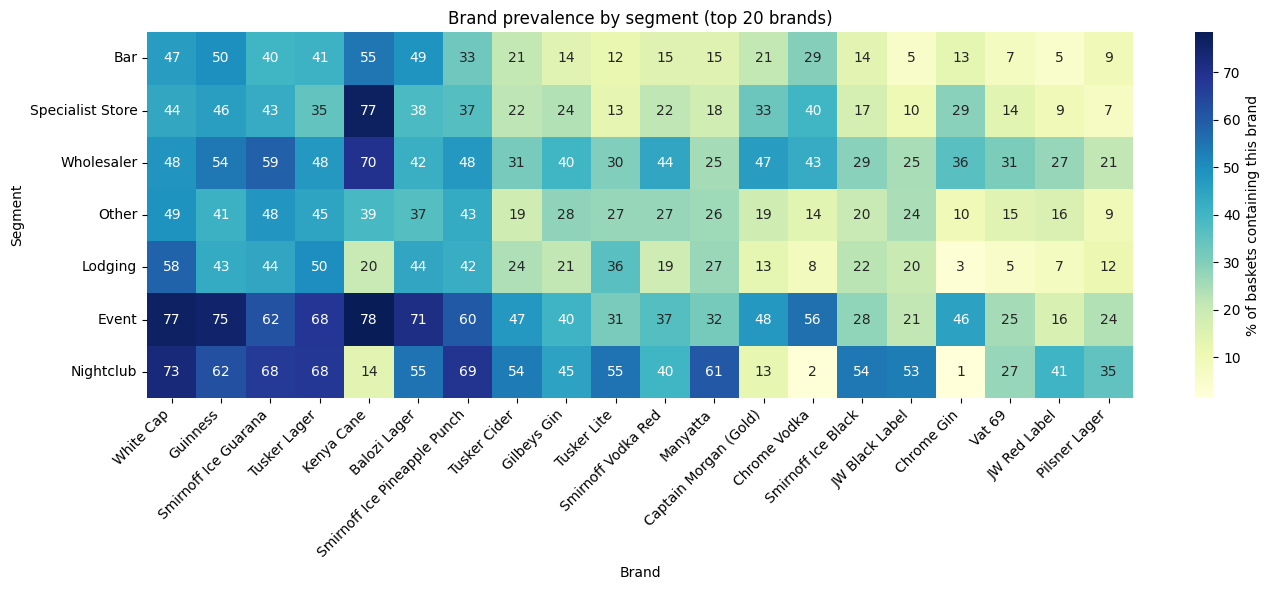

In [125]:
# ── 3. Full brand-prevalence heatmap across ALL segments ──
# This is the most useful full-scale view: for each segment, what % of its
# baskets contain each brand. Segments as rows, top brands as columns.
def brand_prevalence_by_segment(basket_matrices, top_n=20):
    # union of the overall most common brands (by total presence across segments)
    all_presence = pd.concat([m.mean() for m in basket_matrices.values()], axis=1).mean(axis=1)
    top_brands = all_presence.sort_values(ascending=False).head(top_n).index

    rows = {}
    for seg, matrix in basket_matrices.items():
        rows[seg] = matrix.reindex(columns=top_brands, fill_value=False).mean() * 100  # % of baskets

    return pd.DataFrame(rows).T  # segments as rows, brands as columns

prevalence = brand_prevalence_by_segment(basket_matrices, top_n=20)

plt.figure(figsize=(14, 6))
sns.heatmap(prevalence, annot=True, fmt='.0f', cmap='YlGnBu',
            cbar_kws={'label': '% of baskets containing this brand'})
plt.title('Brand prevalence by segment (top 20 brands)')
plt.xlabel('Brand')
plt.ylabel('Segment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Visualize brand popularity across all segments.** Builds a heatmap showing what % of baskets contain each of the top 20 brands, with segments as rows — useful for spotting which brands dominate which outlet types before running any rule mining.

In [126]:
import math

# ── Core formula functions ──
Z_SCORES = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}

def required_occurrences(margin_of_error, confidence_level=0.95, p=0.5):
    """
    How many occurrences (n) you need for a proportion (confidence/lift estimate)
    to be accurate within +/- margin_of_error, at the given confidence level.
    p=0.5 is the worst-case assumption (gives the widest/most conservative interval).
    """
    z = Z_SCORES[confidence_level]
    n = (z**2 * p * (1 - p)) / (margin_of_error ** 2)
    return math.ceil(n)

def margin_of_error(n, confidence_level=0.95, p=0.5):
    """
    The reverse: given n occurrences, what's the actual margin of error
    on any proportion (like confidence) computed from them.
    """
    z = Z_SCORES[confidence_level]
    return z * math.sqrt((p * (1 - p)) / n)


# ── Quick reference: what precision does each MIN_OCCURRENCES buy you? ──
print("Target margin of error -> required occurrences (95% confidence):")
for margin in [0.20, 0.15, 0.10, 0.08, 0.05]:
    n = required_occurrences(margin)
    print(f"  +/-{margin*100:.0f}%  ->  n = {n}")

print("\nCommon MIN_OCCURRENCES values -> resulting margin of error:")
for n in [20, 30, 50, 100, 200]:
    e = margin_of_error(n)
    print(f"  n = {n:>4}  ->  +/-{e*100:.1f}%")


Target margin of error -> required occurrences (95% confidence):
  +/-20%  ->  n = 25
  +/-15%  ->  n = 43
  +/-10%  ->  n = 97
  +/-8%  ->  n = 151
  +/-5%  ->  n = 385

Common MIN_OCCURRENCES values -> resulting margin of error:
  n =   20  ->  +/-21.9%
  n =   30  ->  +/-17.9%
  n =   50  ->  +/-13.9%
  n =  100  ->  +/-9.8%
  n =  200  ->  +/-6.9%


**Statistical formulas: how many occurrences are "enough" to trust a rule.** Defines `required_occurrences` (how many times a pattern needs to occur for a given confidence/precision) and `margin_of_error` (the reverse — how precise a number is, given how many times it occurred). The printed reference table shows the trade-off: more occurrences required means a tighter margin of error.

In [127]:
segment_baskets = {
    'Bar': 54478,
    'Specialist Store': 35814,
    'Wholesaler': 1670,
    'Other': 2385,
    'Lodging': 1552,
    'Event': 729,
    'Nightclub': 644,
}

candidate_n = [20, 30, 50, 100]

rows = []
for seg, n_baskets in segment_baskets.items():
    for n in candidate_n:
        min_support = max(n / n_baskets, 0.01)
        rows.append({
            'segment': seg,
            'baskets': n_baskets,
            'MIN_OCCURRENCES': n,
            'implied_min_support': round(min_support * 100, 2),
            'margin_of_error_%': round(margin_of_error(n) * 100, 1),
        })

result = pd.DataFrame(rows)
print(result.pivot(index='segment', columns='MIN_OCCURRENCES', values='margin_of_error_%'))
print()
print(result.pivot(index='segment', columns='MIN_OCCURRENCES', values='implied_min_support'))


MIN_OCCURRENCES    20    30    50   100
segment                                
Bar               21.9  17.9  13.9  9.8
Event             21.9  17.9  13.9  9.8
Lodging           21.9  17.9  13.9  9.8
Nightclub         21.9  17.9  13.9  9.8
Other             21.9  17.9  13.9  9.8
Specialist Store  21.9  17.9  13.9  9.8
Wholesaler        21.9  17.9  13.9  9.8

MIN_OCCURRENCES    20    30    50     100
segment                                  
Bar               1.00  1.00  1.00   1.00
Event             2.74  4.12  6.86  13.72
Lodging           1.29  1.93  3.22   6.44
Nightclub         3.11  4.66  7.76  15.53
Other             1.00  1.26  2.10   4.19
Specialist Store  1.00  1.00  1.00   1.00
Wholesaler        1.20  1.80  2.99   5.99


**Apply the formulas to this dataset's actual segment sizes.** For each segment and a few candidate `MIN_OCCURRENCES` values (20/30/50/100), computes the resulting margin of error and the `min_support` percentage that implies — this is what justified using a different occurrence threshold per segment rather than one blanket number.

In [128]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

def get_frequent_itemsets(matrix, min_support, use_fpgrowth=False):
    fn = fpgrowth if use_fpgrowth else apriori
    return fn(matrix, min_support=min_support, use_colnames=True, max_len=2)


**Define the frequent itemset finder.** A wrapper around `mlxtend`'s `apriori`/`fpgrowth` — finds brand combinations (limited to pairs, `max_len=2`) that occur often enough to clear a given `min_support` threshold. `fpgrowth` is used as a faster alternative to `apriori` for larger matrices.

In [129]:
MIN_OCCURRENCES_BY_SEGMENT = {
    'Bar': 100,               # floor-bound anyway — higher number costs nothing, tightens precision for free
    'Specialist Store': 100,  # same reasoning
    'Wholesaler': 30,
    'Other': 30,
    'Lodging': 30,
    'Event': 20,              # thin — needs a lower bar just to get any itemsets at all
    'Nightclub': 20,          # same
}

frequent_itemsets = {}
for seg, matrix in basket_matrices.items():
    n_baskets = matrix.shape[0]
    if n_baskets < 200:
        print(f"Skipping {seg} — only {n_baskets} baskets, too thin to trust")
        continue

    min_occ = MIN_OCCURRENCES_BY_SEGMENT.get(seg, 30)  # fallback to 30 for any segment not listed
    min_support = max(min_occ / n_baskets, 0.01)
    itemsets = get_frequent_itemsets(matrix, min_support, use_fpgrowth=(n_baskets < 5000))

    if itemsets.empty:
        print(f"{seg}: no itemsets at min_support={min_support:.4f} (MIN_OCCURRENCES={min_occ}) — try lowering it")
        continue

    frequent_itemsets[seg] = itemsets
    print(f"{seg}: MIN_OCCURRENCES={min_occ}, min_support={min_support:.4f}, {len(itemsets)} itemsets found")


Bar: MIN_OCCURRENCES=100, min_support=0.0100, 423 itemsets found
Specialist Store: MIN_OCCURRENCES=100, min_support=0.0100, 546 itemsets found
Wholesaler: MIN_OCCURRENCES=30, min_support=0.0180, 944 itemsets found
Other: MIN_OCCURRENCES=30, min_support=0.0126, 598 itemsets found
Lodging: MIN_OCCURRENCES=30, min_support=0.0193, 296 itemsets found
Event: MIN_OCCURRENCES=20, min_support=0.0274, 561 itemsets found
Nightclub: MIN_OCCURRENCES=20, min_support=0.0311, 584 itemsets found


**Run frequent itemset mining per segment, with a tiered occurrence threshold.** Bar and Specialist Store get a stricter threshold (100) since their size absorbs it for free; the thinner segments get lower thresholds (20–30) so they still produce usable results. Segments with fewer than 200 baskets are skipped entirely as too thin to trust.

MIN_OCCURRENCES = 30

frequent_itemsets = {}
for seg, matrix in basket_matrices.items():
    n_baskets = matrix.shape[0]
    if n_baskets < 200:
        print(f"Skipping {seg} — only {n_baskets} baskets, too thin to trust")
        continue

    min_support = max(MIN_OCCURRENCES / n_baskets, 0.01)  # never go below 1%
    itemsets = get_frequent_itemsets(matrix, min_support, use_fpgrowth=(n_baskets < 5000))

    if itemsets.empty:
        print(f"{seg}: no itemsets at min_support={min_support:.4f} — try lowering MIN_OCCURRENCES")
        continue

    frequent_itemsets[seg] = itemsets
    print(f"{seg}: min_support={min_support:.4f}, {len(itemsets)} itemsets found")


In [130]:
all_rules = {}
for seg, itemsets in frequent_itemsets.items():
    rules = association_rules(itemsets, metric="lift", min_threshold=1.0, num_itemsets=len(itemsets))
    all_rules[seg] = rules


**Generate association rules (support/confidence/lift) from the frequent itemsets.** Note: this version has a since-corrected issue — `num_itemsets` is set to the itemset table's row count instead of the actual basket count for that segment. Left here unedited; the corrected version runs in the next cell.

In [131]:
# FIX: num_itemsets should be the actual basket/transaction count for each segment,
# not len(itemsets) (the number of rows in the frequent itemsets table).
all_rules = {}
for seg, itemsets in frequent_itemsets.items():
    n_baskets = basket_matrices[seg].shape[0]
    rules = association_rules(itemsets, metric="lift", min_threshold=1.0, num_itemsets=n_baskets)
    all_rules[seg] = rules
print("all_rules recomputed with corrected num_itemsets (actual basket counts)")

all_rules recomputed with corrected num_itemsets (actual basket counts)


**Corrected version of the rule generation above.** Recomputes `all_rules` using the actual basket count per segment for `num_itemsets`, which is the value `mlxtend` expects — this is the version actually used for everything downstream.

### 1.)Support answers "is this combination common enough to matter at all?" It's the first filter — a relationship that happens once in 10,000 baskets isn't a business pattern, it's a fluke, no matter how strong it looks on other metrics.

### 2.)Confidence: This is the number closest to a real-world instruction — "when a rep sells A, how often does B also get bought." It's what you'd literally tell a rep as a probability.

### 3.)Lift :What it measures: Whether A and B co-occur more than random chance, given how common each one already is, would predict. This is the metric that actually answers "is this a real relationship."
#### Lift = 1 → no relationship. A and B occur together exactly as often as their individual popularity predicts. Pure coincidence.
#### Lift > 1 → positive relationship — the higher above 1, the stronger the real pull between them. This is what you act on.
#### Lift < 1 → negative relationship — the two items actually appear together less than chance would predict (worth knowing too — don't bundle these).

In [132]:
def get_actionable_rules(rules, min_confidence=0.30, min_lift=1.2, top_n=10):
    filtered = rules[(rules['confidence'] >= min_confidence) & (rules['lift'] >= min_lift)]
    filtered = filtered.sort_values('lift', ascending=False).head(top_n).copy()
    filtered['antecedents'] = filtered['antecedents'].apply(lambda x: ', '.join(x))
    filtered['consequents'] = filtered['consequents'].apply(lambda x: ', '.join(x))
    return filtered[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

final_rules = {}
for seg, rules in all_rules.items():
    top = get_actionable_rules(rules)
    final_rules[seg] = top
    print(f"\n=== {seg} ===")
    print(top.to_string(index=False))



=== Bar ===
      antecedents    consequents  support  confidence     lift
   JW Black Label   JW Red Label 0.018558    0.345523 7.541425
     JW Red Label JW Black Label 0.018558    0.405048 7.541425
    Black & White         Vat 69 0.015988    0.390934 5.360503
   JW Black Label         Vat 69 0.017659    0.328776 4.508202
     JW Red Label         Vat 69 0.014868    0.324519 4.449826
  White Cap Crisp    Tusker Lite 0.010408    0.525000 4.311268
Tusker Malt Lager    Tusker Lite 0.031774    0.487468 4.003060
    Black & White         Bond 7 0.012500    0.305655 3.842060
     JW Red Label         Bond 7 0.013877    0.302885 3.807233
           Vat 69         Bond 7 0.022009    0.301787 3.793437

=== Specialist Store ===
      antecedents    consequents  support  confidence     lift
     JW Red Label JW Black Label 0.036745    0.391201 3.866024
   JW Black Label   JW Red Label 0.036745    0.363135 3.866024
Tusker Malt Lager    Tusker Lite 0.029458    0.487073 3.774130
  Gordons Dry Gi

**Filter down to the rules worth acting on.** Defines `get_actionable_rules`, which keeps only rules meeting a minimum confidence (30%) and lift (1.2), sorted by lift, top 10 per segment. This turns hundreds of statistically-valid-but-noisy rules into a short, trustworthy list — `final_rules` is what gets saved and acted on.

In [133]:
print("NOTE: 'Other' combines Recreation, Restaurant, Marketplace, and Supermarket outlets —")
print("it is not one coherent outlet type. Interpret its rules with extra caution.")

NOTE: 'Other' combines Recreation, Restaurant, Marketplace, and Supermarket outlets —
it is not one coherent outlet type. Interpret its rules with extra caution.


**Caveat for the "Other" segment.** A reminder that "Other" is an artificial bucket combining Recreation, Restaurant, Marketplace, and Supermarket outlets — not one real outlet type — so its rules should be read with extra caution.

In [134]:
import os
os.makedirs("market_basket_results", exist_ok=True)
for seg, rules in final_rules.items():
    rules.to_csv(f"market_basket_results/{seg.replace(' ', '_')}_rules.csv", index=False)


**Export the final rules.** Saves each segment's top rules from `final_rules` to its own CSV file in `market_basket_results/` — this is the actual deliverable a rep-facing cheat sheet would be built from.

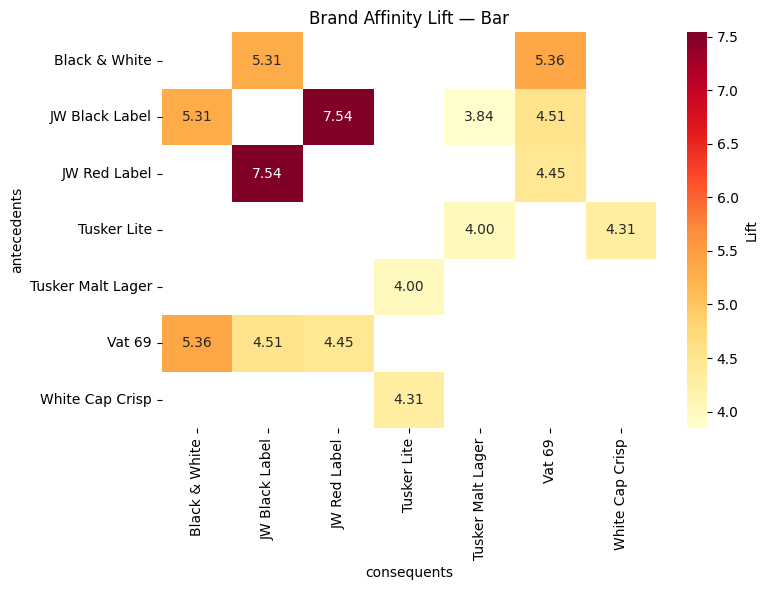

In [135]:


def plot_lift_heatmap(rules, seg_name, top_n=15):
    top = rules.sort_values('lift', ascending=False).head(top_n)
    pivot = top.assign(
        antecedents=top['antecedents'].apply(lambda x: ', '.join(x) if isinstance(x, frozenset) else x),
        consequents=top['consequents'].apply(lambda x: ', '.join(x) if isinstance(x, frozenset) else x)
    ).pivot(index='antecedents', columns='consequents', values='lift')

    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Lift'})
    plt.title(f"Brand Affinity Lift — {seg_name}")
    plt.tight_layout()
    plt.show()

plot_lift_heatmap(all_rules['Bar'], 'Bar')


**Define and demo the lift heatmap.** `plot_lift_heatmap` visualizes the top 15 rules for a segment as a color-coded grid of lift values — darker/redder means a stronger relationship. Called here for Bar as an example.

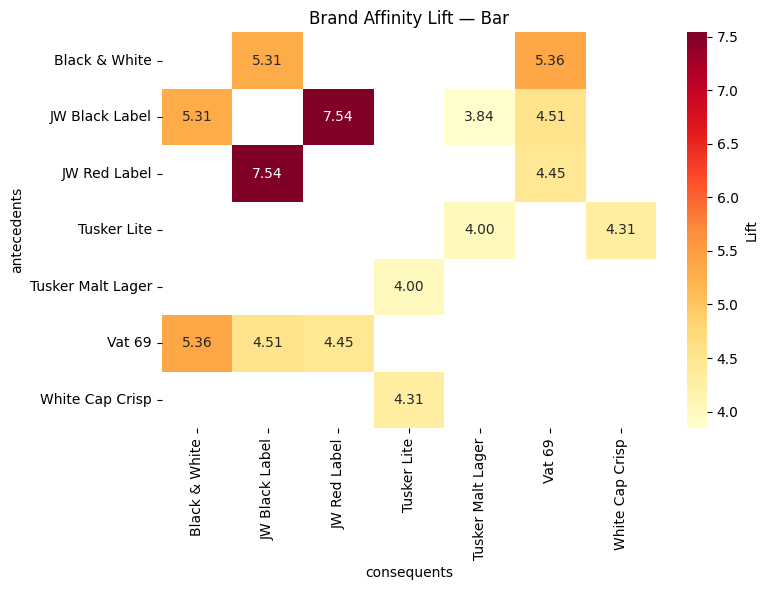

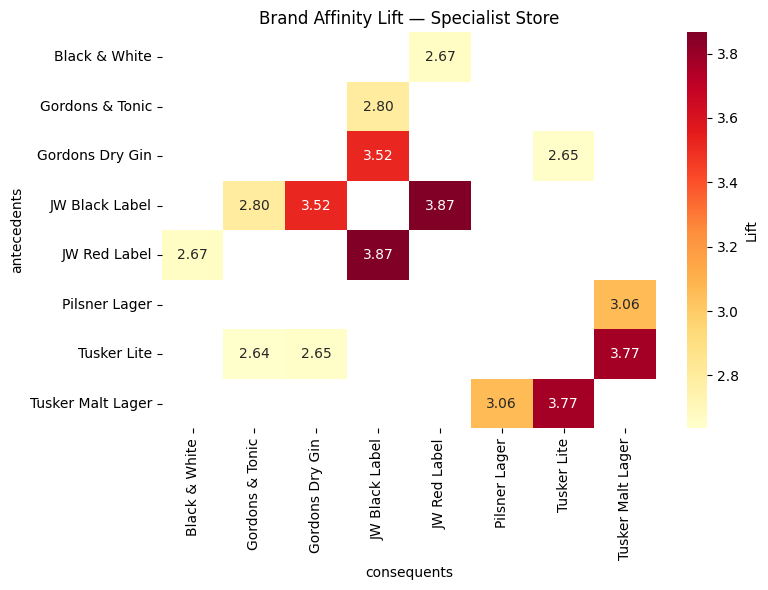

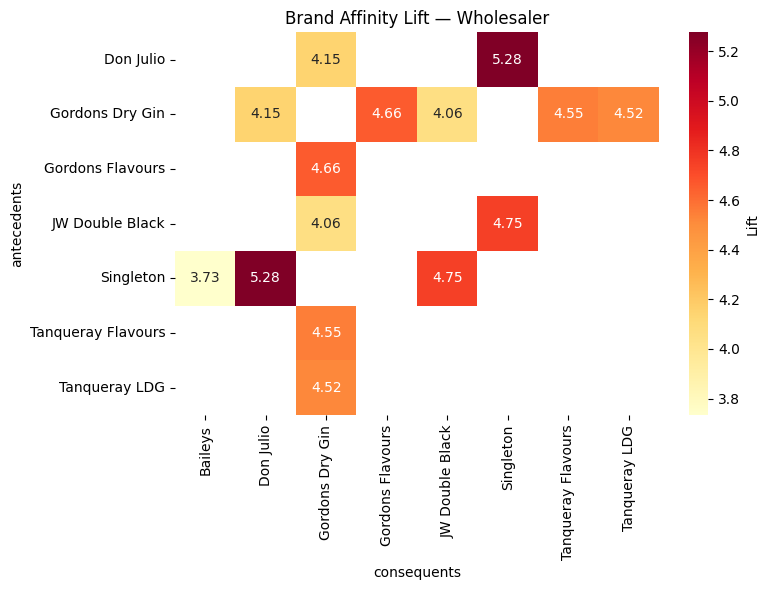

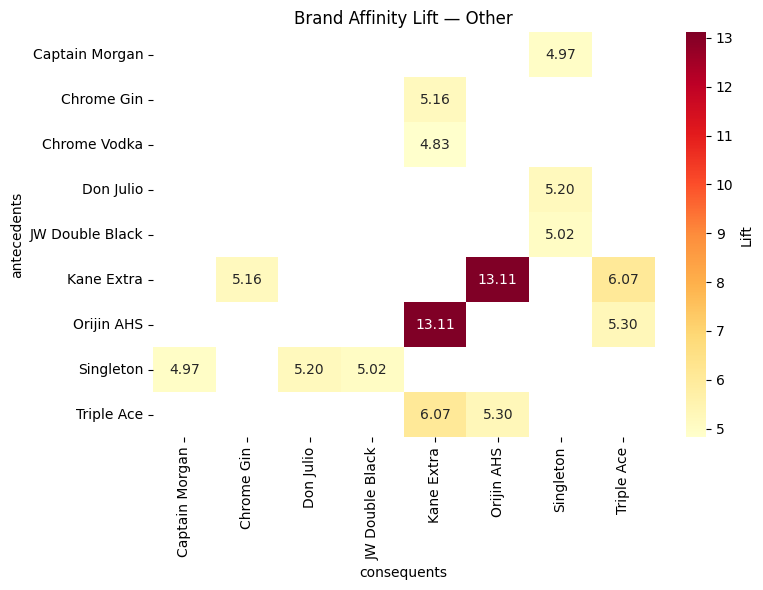

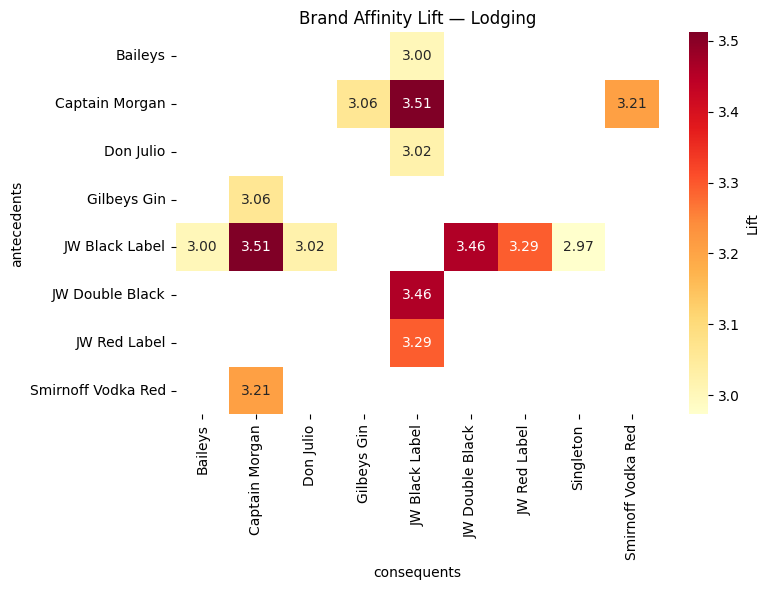

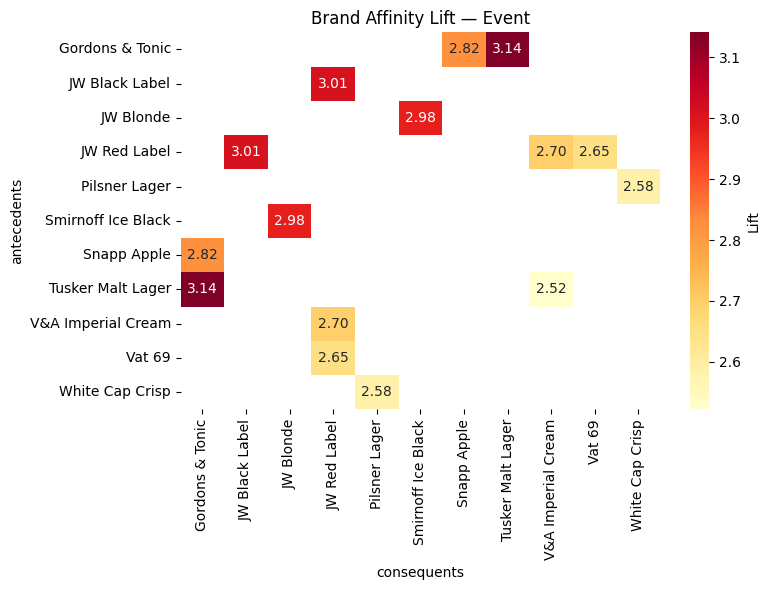

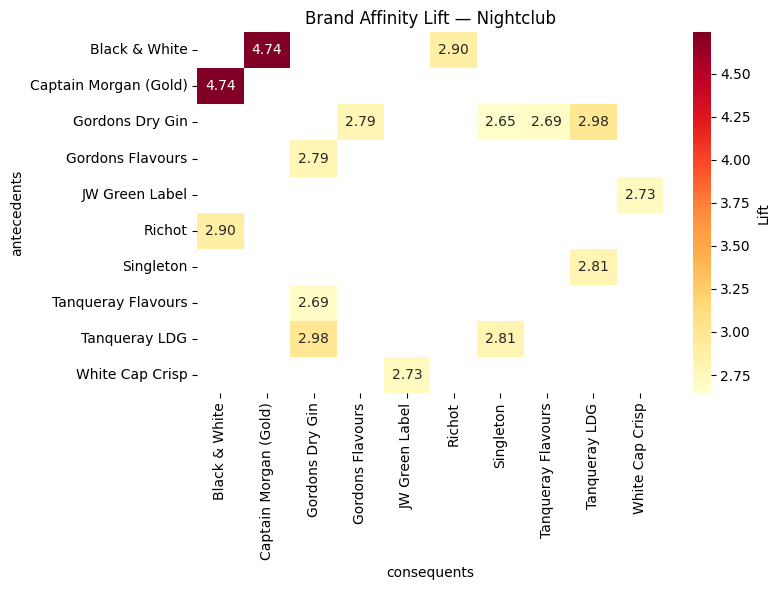

In [136]:
for seg, rules in all_rules.items():
    if rules.empty:
        print(f"Skipping {seg} — no rules to plot")
        continue
    plot_lift_heatmap(rules, seg)


**Run the lift heatmap for every segment.** Loops through all segments' rule tables and plots one heatmap each, skipping any segment with no rules.

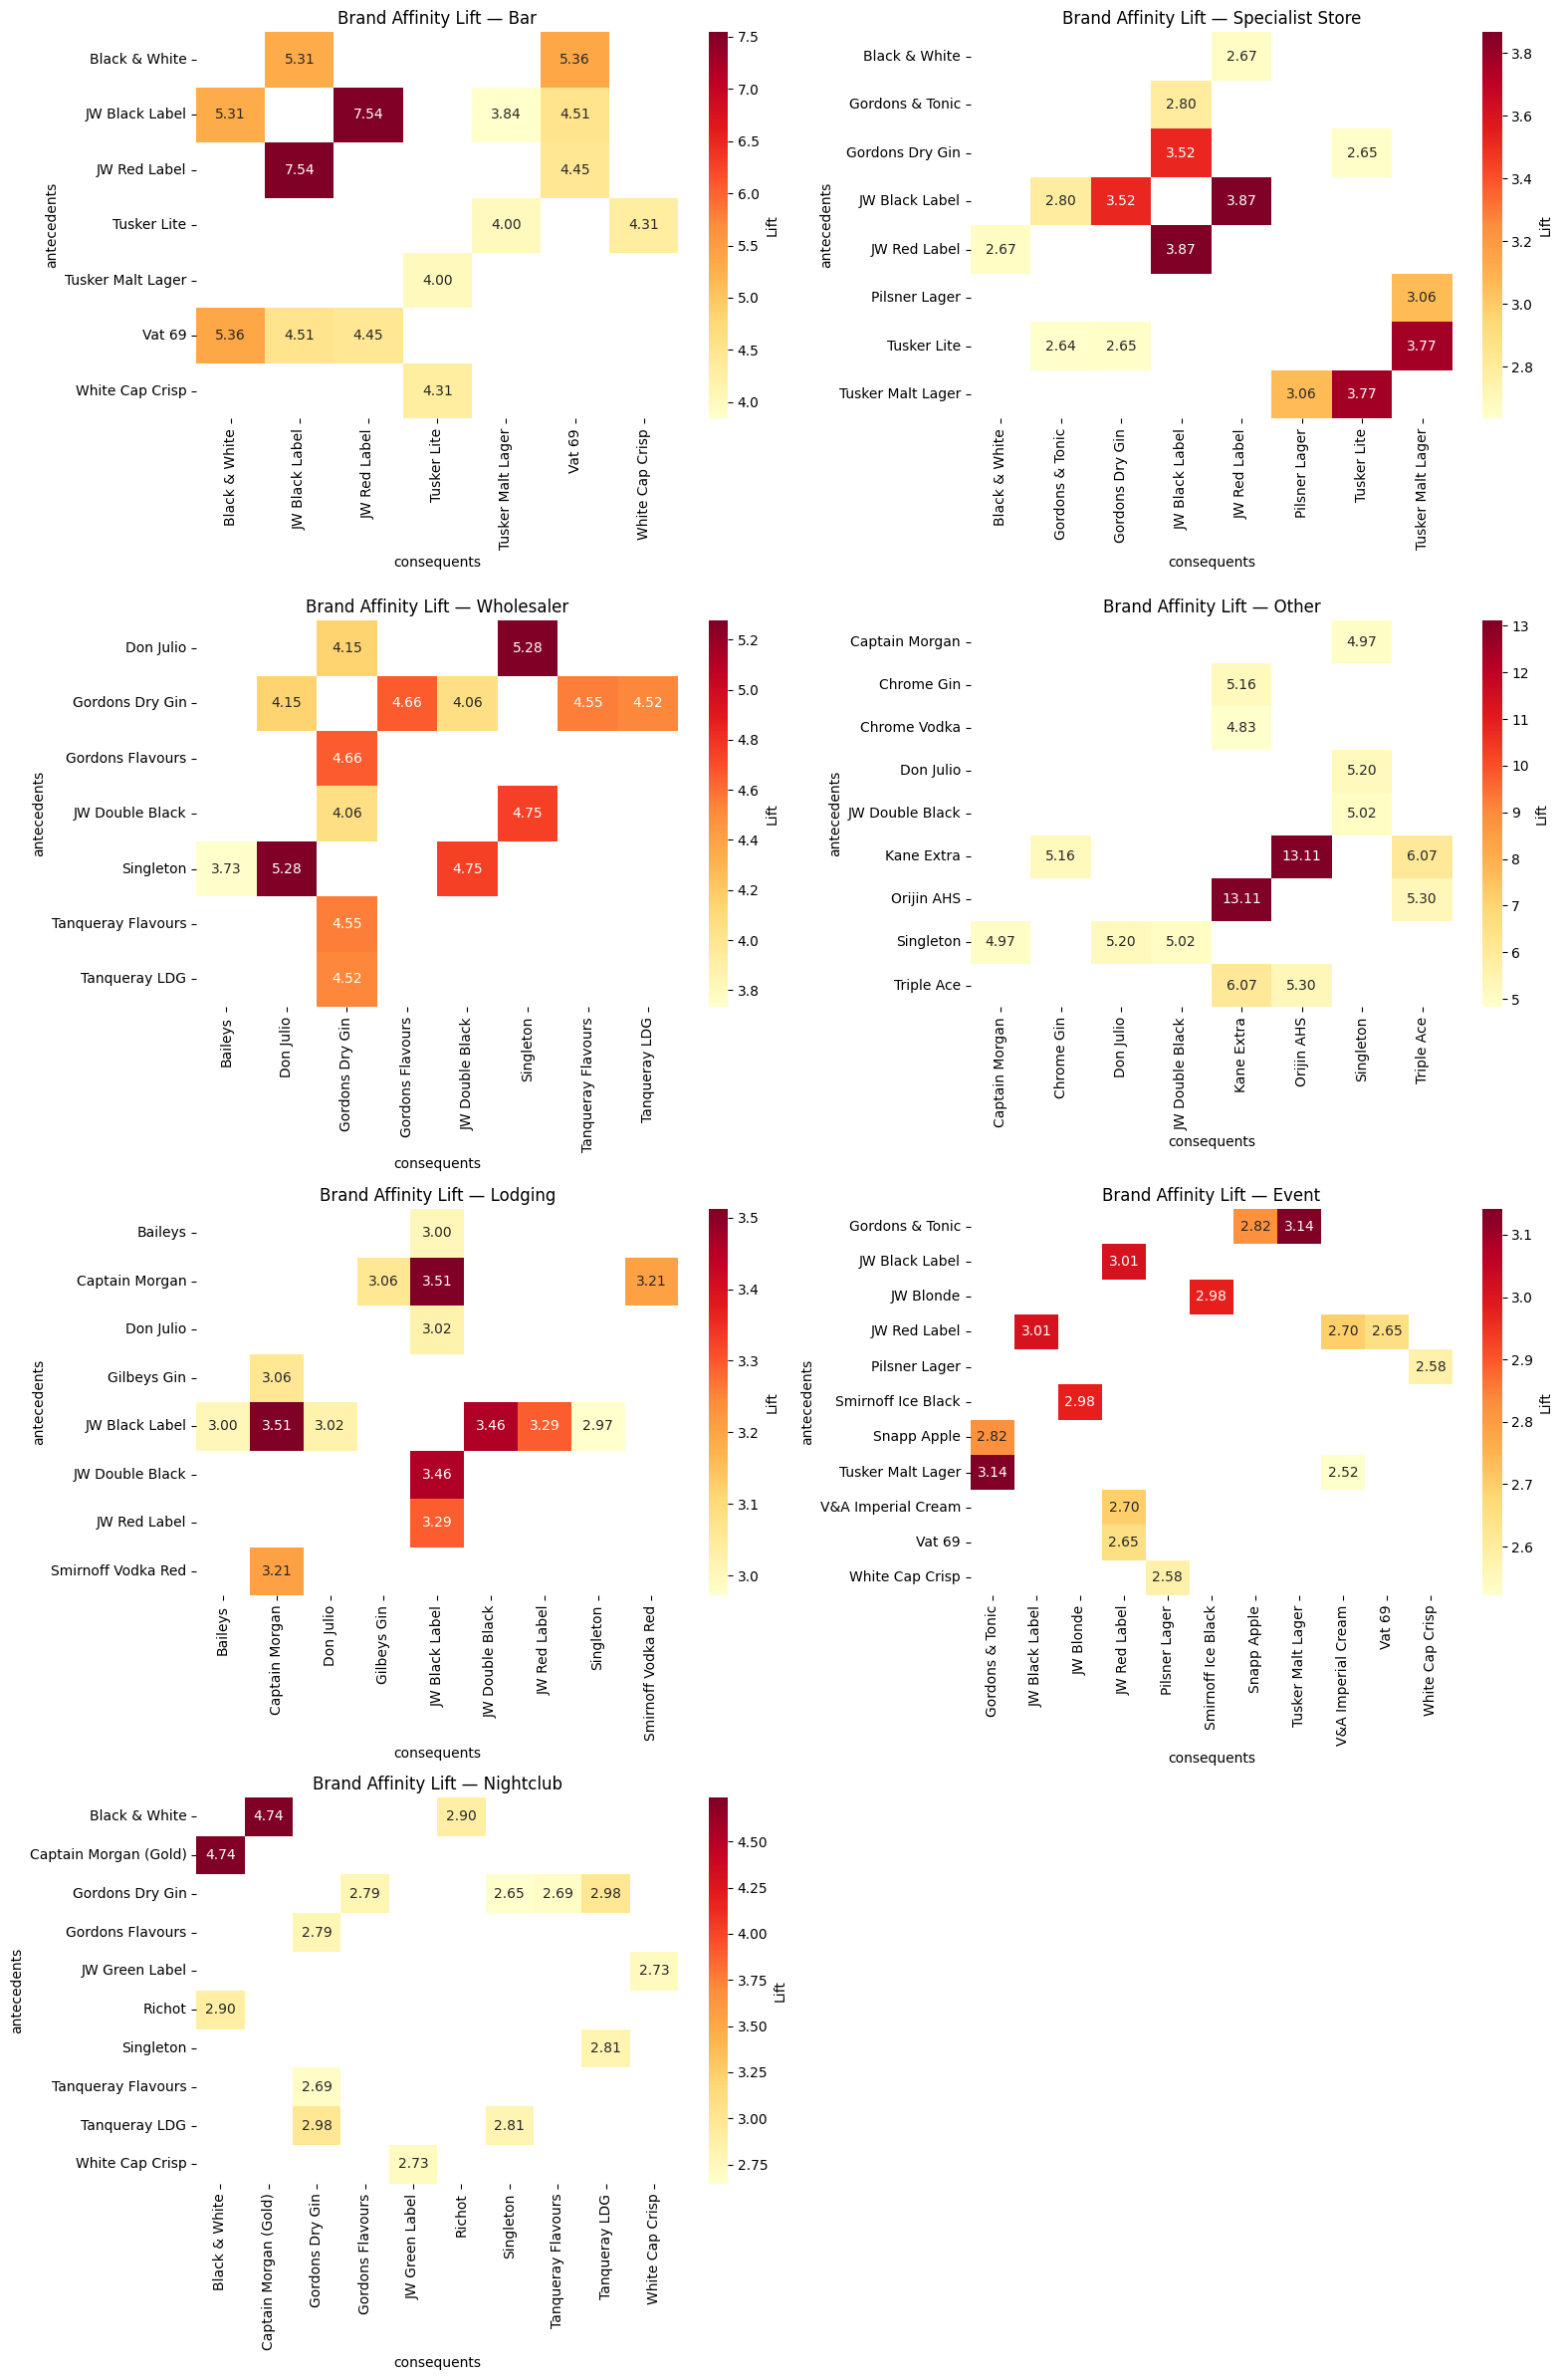

In [137]:
n_segs = len(all_rules)
n_cols = 2
n_rows = (n_segs + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows))
axes = axes.flatten()

for i, (seg, rules) in enumerate(all_rules.items()):
    if rules.empty:
        axes[i].set_visible(False)
        continue

    top = rules.sort_values('lift', ascending=False).head(15)
    pivot = top.assign(
        antecedents=top['antecedents'].apply(lambda x: ', '.join(x) if isinstance(x, frozenset) else x),
        consequents=top['consequents'].apply(lambda x: ', '.join(x) if isinstance(x, frozenset) else x)
    ).pivot(index='antecedents', columns='consequents', values='lift')

    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Lift'}, ax=axes[i])
    axes[i].set_title(f"Brand Affinity Lift — {seg}")

# hide any unused subplot slots
for j in range(len(all_rules), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


**Combined view: all segment heatmaps in one figure.** Same lift heatmaps as above, but arranged as a grid of subplots so all segments can be compared side by side in a single image instead of scrolling through separate plots.

/var/folders/tf/4wkr_3ls3jb9f452xff6b1880000gn/T/ipykernel_2465/3518986646.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


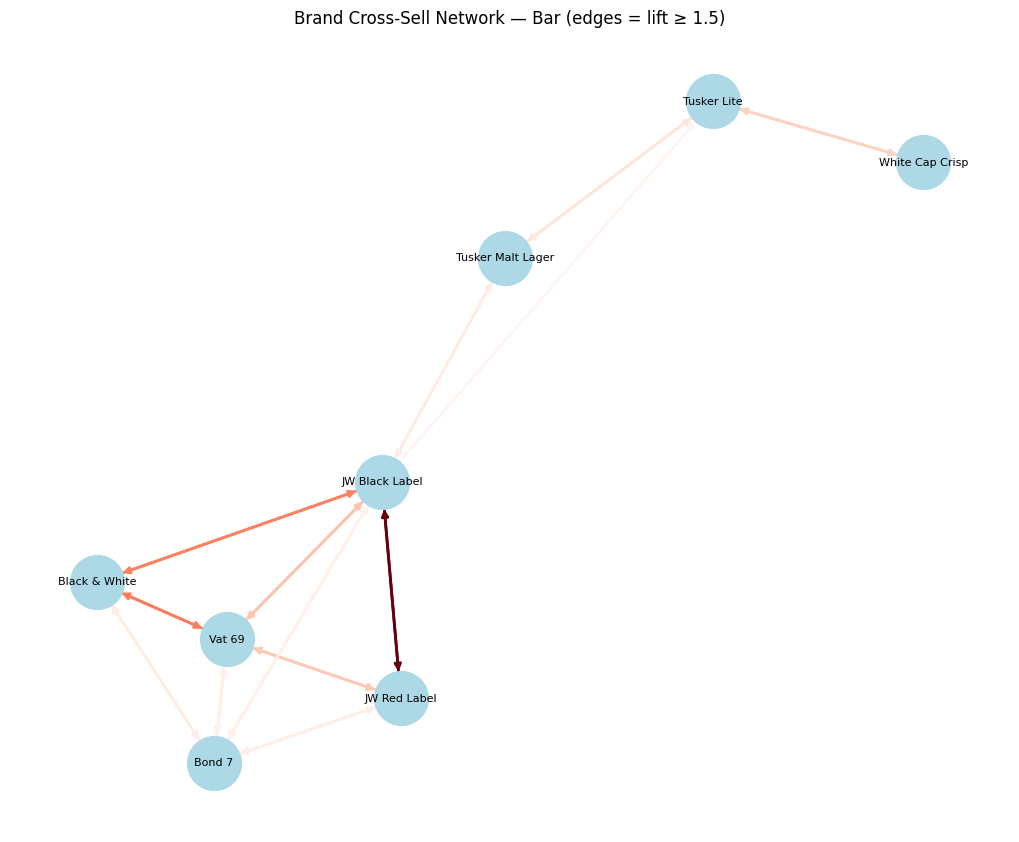

In [138]:

def plot_rule_network(rules, seg_name, min_lift=1.5, top_n=25):
    strong_rules = rules[rules['lift'] >= min_lift].sort_values('lift', ascending=False).head(top_n)

    G = nx.DiGraph()
    for _, row in strong_rules.iterrows():
        a = ', '.join(row['antecedents'])
        c = ', '.join(row['consequents'])
        G.add_edge(a, c, weight=row['lift'])

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=0.8, seed=42)
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1500,
            font_size=8, edge_color=weights, edge_cmap=plt.cm.Reds, width=2, arrows=True)
    plt.title(f"Brand Cross-Sell Network — {seg_name} (edges = lift ≥ {min_lift})")
    plt.tight_layout()
    plt.show()

plot_rule_network(all_rules['Bar'], 'Bar')


**Define and demo the cross-sell network graph.** `plot_rule_network` draws brand relationships as a directed graph — an arrow from A to B means buying A predicts buying B beyond chance (lift ≥ threshold). Called here for Bar as an example.

/var/folders/tf/4wkr_3ls3jb9f452xff6b1880000gn/T/ipykernel_2465/3518986646.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


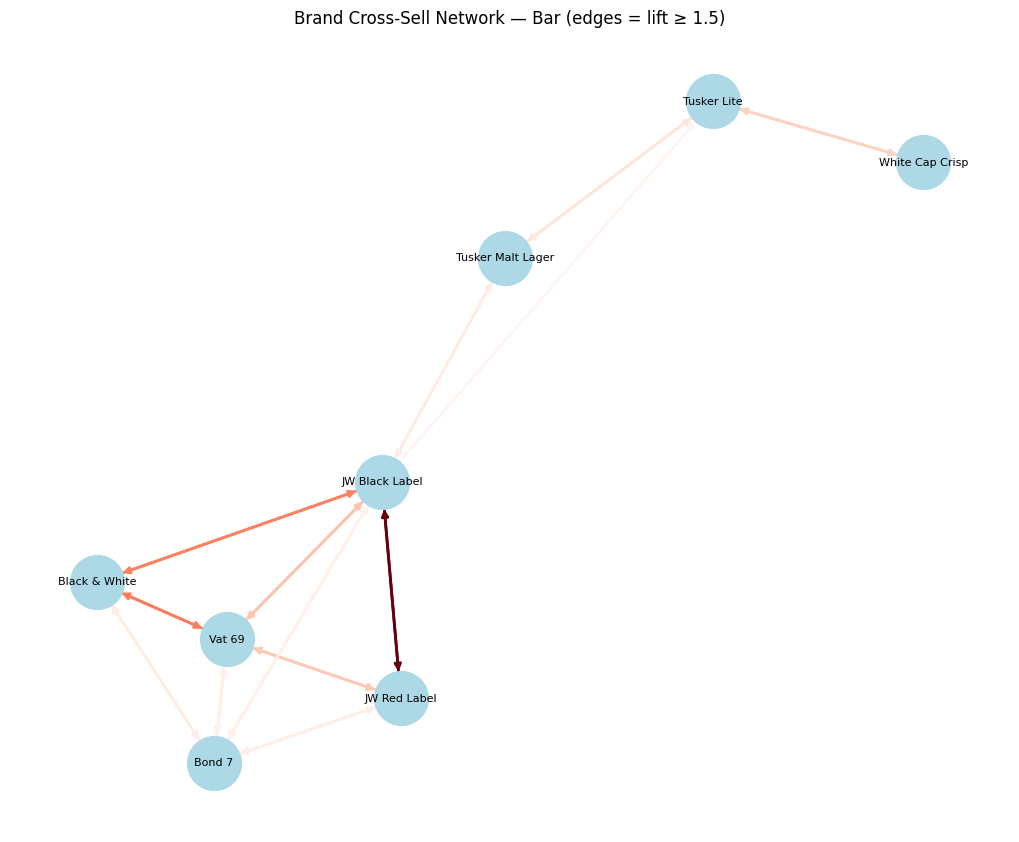

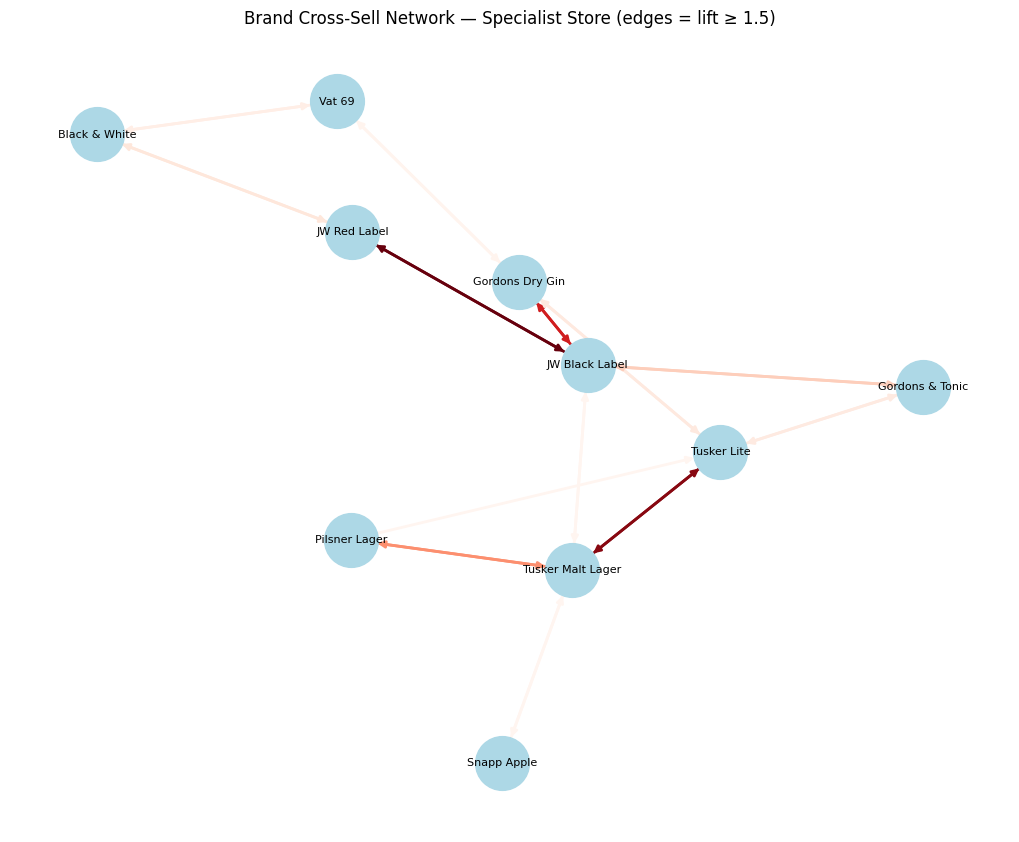

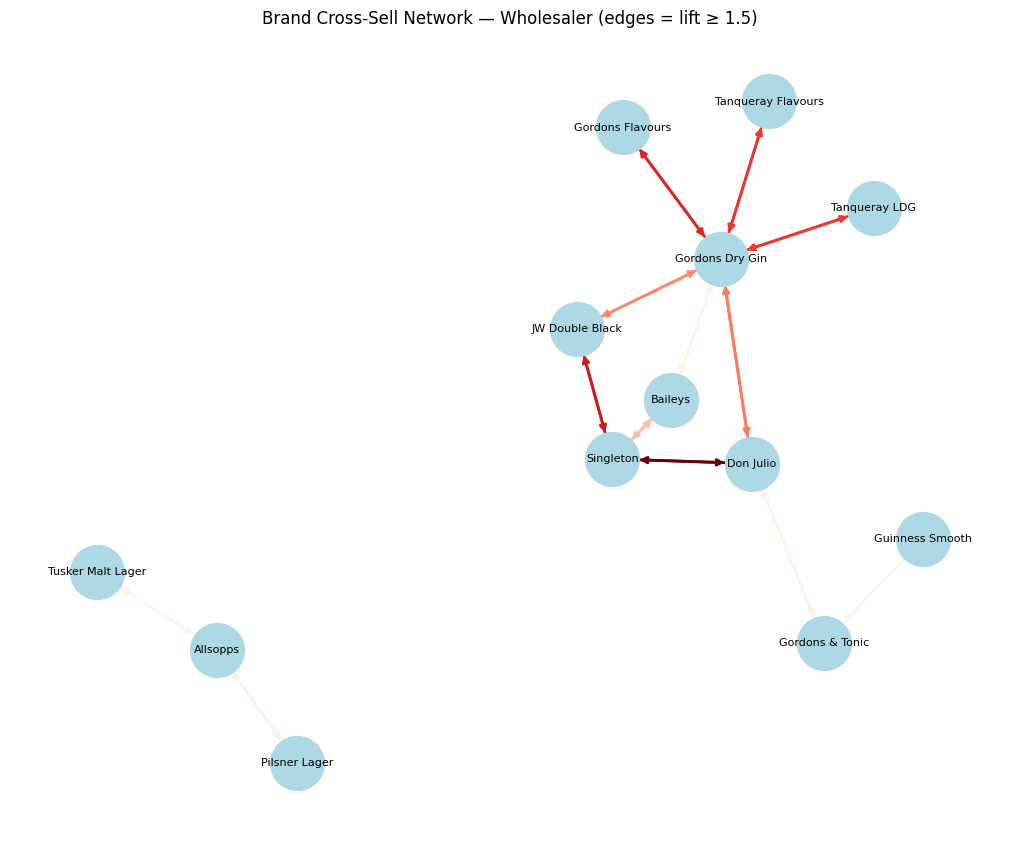

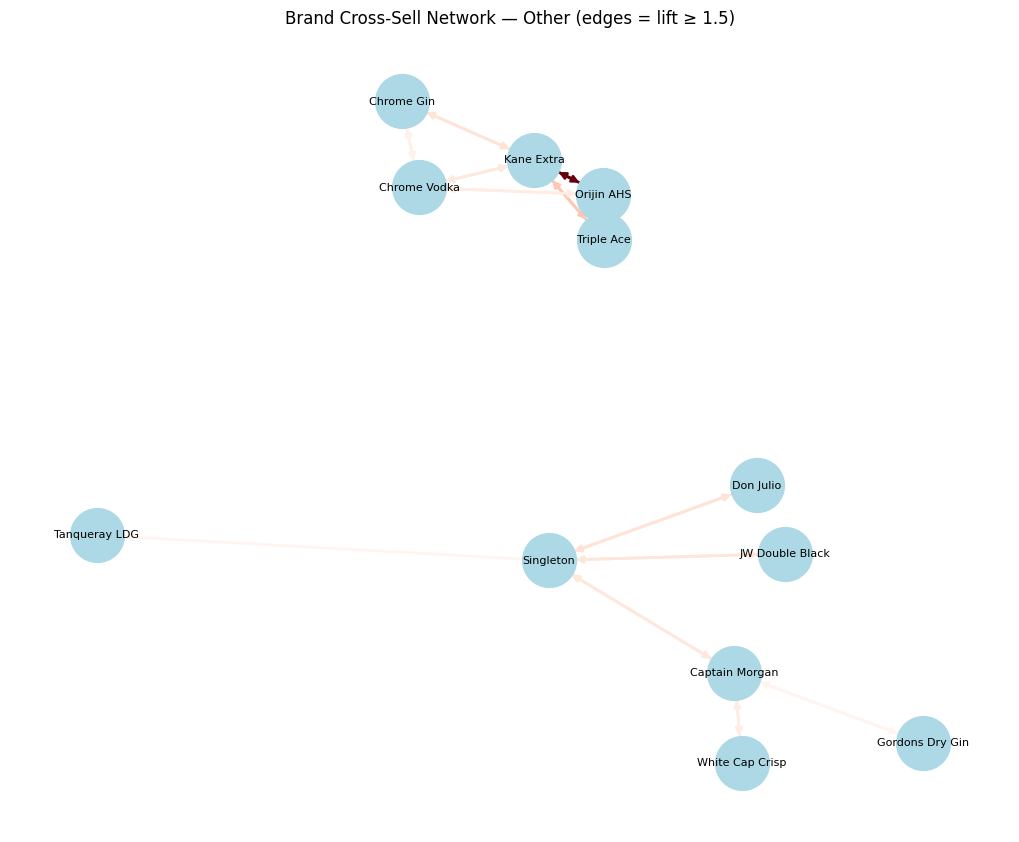

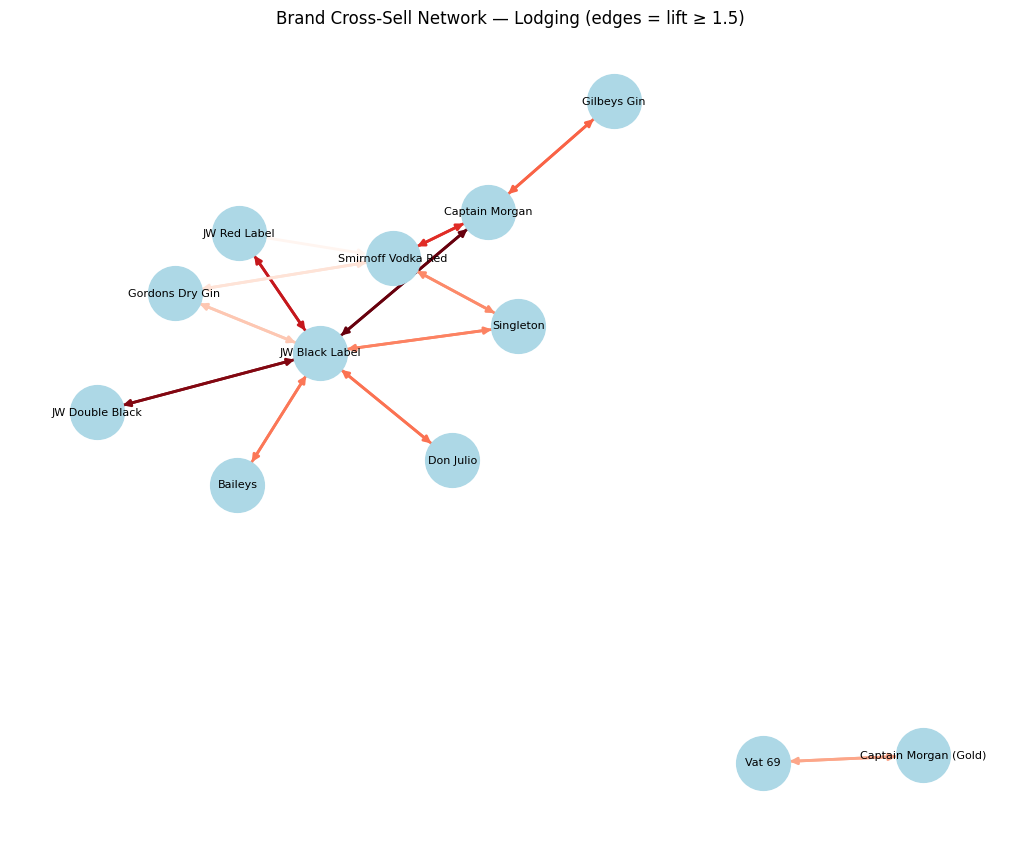

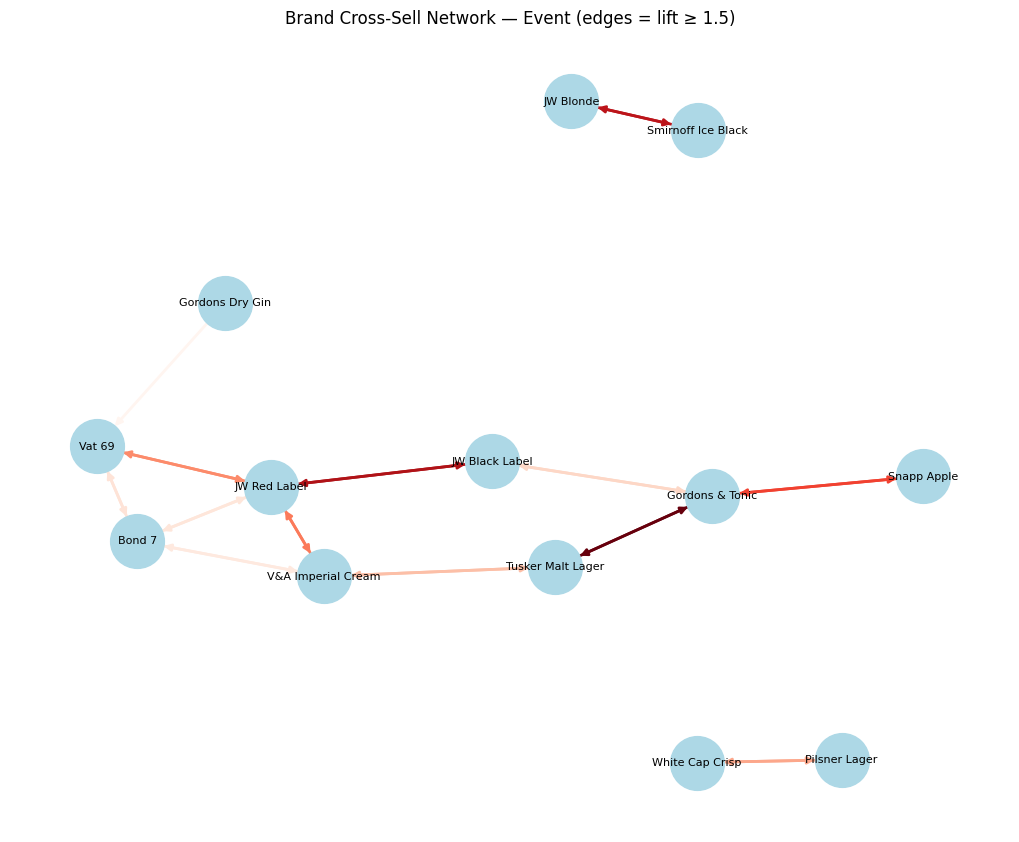

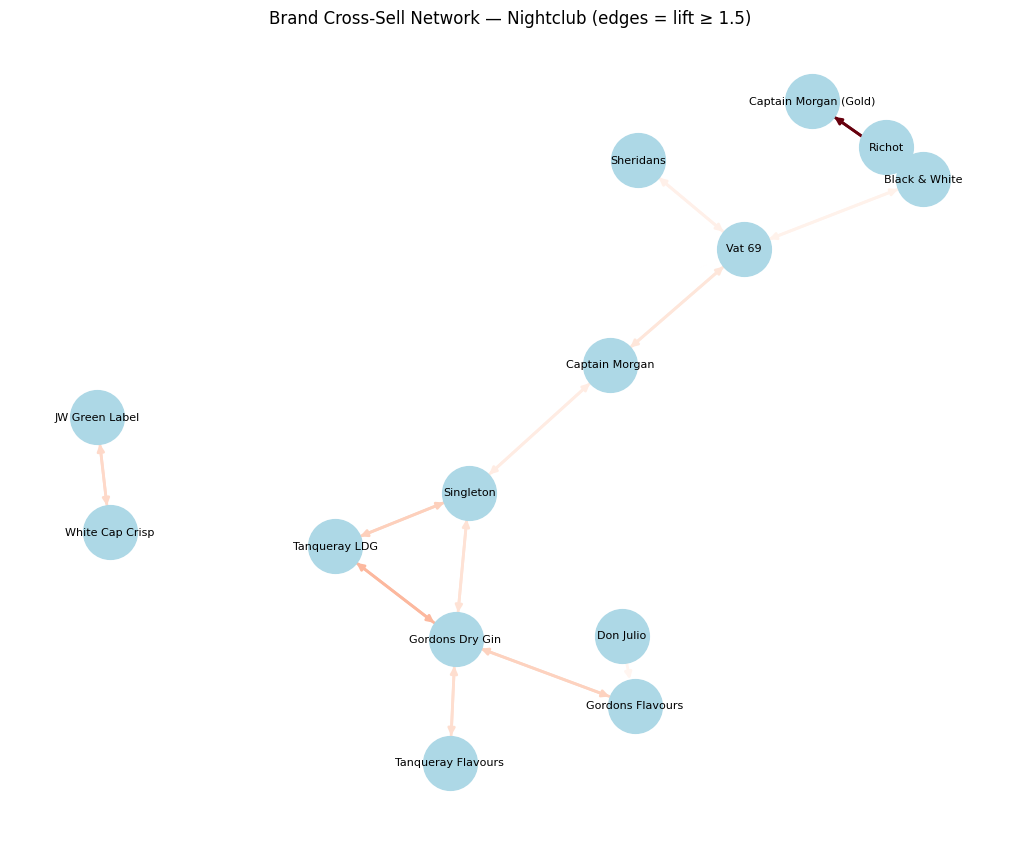

In [139]:
for seg, rules in all_rules.items():
    if rules.empty:
        print(f"Skipping {seg} — no rules to plot")
        continue
    plot_rule_network(rules, seg)


**Run the network graph for every segment.** Loops through all segments and plots one cross-sell network per segment, skipping any with no rules.

In [140]:
mid_date = df['visit_date'].median()
df_h1, df_h2 = df[df['visit_date'] <= mid_date], df[df['visit_date'] > mid_date]
# rerun 3b–3d on each, compare the resulting rule tables for the same segment


**Split the data into two time halves.** Divides the cleaned dataset at its midpoint date into `df_h1` (earlier half) and `df_h2` (later half) — the first step in checking whether a rule holds up consistently over time, or whether it's just an artifact of one season/period.

In [141]:
def run_full_pipeline(data, min_occ_by_segment, min_basket_threshold=200):
    matrices = {seg: build_basket_matrix(data[data['segment_grouped'] == seg])
                for seg in data['segment_grouped'].unique()}
    rules_out = {}
    for seg, matrix in matrices.items():
        n_baskets = matrix.shape[0]
        if n_baskets < min_basket_threshold:
            continue
        min_occ = min_occ_by_segment.get(seg, 30)
        min_support = max(min_occ / n_baskets, 0.01)
        itemsets = get_frequent_itemsets(matrix, min_support, use_fpgrowth=(n_baskets < 5000))
        if itemsets.empty:
            continue
        rules = association_rules(itemsets, metric="lift", min_threshold=1.0, num_itemsets=n_baskets)
        rules_out[seg] = rules
    return rules_out

all_rules_h1 = run_full_pipeline(df_h1, MIN_OCCURRENCES_BY_SEGMENT)
all_rules_h2 = run_full_pipeline(df_h2, MIN_OCCURRENCES_BY_SEGMENT)
print("Pipeline re-run on both time halves — h1 and h2 rule tables ready for comparison")

Pipeline re-run on both time halves — h1 and h2 rule tables ready for comparison


**Re-run the entire rule-mining pipeline separately on each time half.** Wraps the basket-matrix → itemsets → rules steps into one reusable function, then runs it on `df_h1` and `df_h2` independently — producing two separate rule tables per segment to compare against the full-data rules.

In [142]:
def get_top_rules_raw(rules, min_confidence=0.30, min_lift=1.2, top_n=10):
    filtered = rules[(rules['confidence'] >= min_confidence) & (rules['lift'] >= min_lift)]
    return filtered.sort_values('lift', ascending=False).head(top_n)


def validate_seasonality(all_rules_full, all_rules_h1, all_rules_h2, lift_tolerance=0.5):
    results = {}
    for seg, rules in all_rules_full.items():
        top_rules = get_top_rules_raw(rules)
        h1, h2 = all_rules_h1.get(seg, pd.DataFrame()), all_rules_h2.get(seg, pd.DataFrame())
        rows = []
        for _, row in top_rules.iterrows():
            ant, cons, full_lift = row['antecedents'], row['consequents'], row['lift']

            def lookup(rdf):
                if rdf.empty:
                    return None
                m = rdf[(rdf['antecedents'] == ant) & (rdf['consequents'] == cons)]
                return m['lift'].iloc[0] if len(m) else None

            l1, l2 = lookup(h1), lookup(h2)
            holds = all(v is not None and abs(v - full_lift) <= lift_tolerance * full_lift for v in [l1, l2])
            rows.append({
                'antecedents': ', '.join(ant), 'consequents': ', '.join(cons),
                'full_lift': round(full_lift, 2),
                'lift_h1': round(l1, 2) if l1 is not None else None,
                'lift_h2': round(l2, 2) if l2 is not None else None,
                'seasonally_stable': holds
            })
        results[seg] = pd.DataFrame(rows)
    return results

seasonality_check = validate_seasonality(all_rules, all_rules_h1, all_rules_h2)
for seg, res in seasonality_check.items():
    print(f"\n=== {seg} ===")
    print(res.to_string(index=False))


=== Bar ===
      antecedents    consequents  full_lift  lift_h1  lift_h2  seasonally_stable
   JW Black Label   JW Red Label       7.54     7.19     8.00               True
     JW Red Label JW Black Label       7.54     7.19     8.00               True
    Black & White         Vat 69       5.36     4.88     5.81               True
   JW Black Label         Vat 69       4.51     4.47     4.58               True
     JW Red Label         Vat 69       4.45     4.61     4.27               True
  White Cap Crisp    Tusker Lite       4.31      NaN     4.14              False
Tusker Malt Lager    Tusker Lite       4.00     4.22     3.77               True
    Black & White         Bond 7       3.84     3.68     4.00               True
     JW Red Label         Bond 7       3.81     3.72     3.93               True
           Vat 69         Bond 7       3.79     3.84     3.74               True

=== Specialist Store ===
      antecedents    consequents  full_lift  lift_h1  lift_h2  seasona

**Check which top rules hold up across both time periods.** Compares each segment's top rules (by lift) against the matching rule in the h1 and h2 rule tables. A rule is only marked `seasonally_stable = True` if it reappears with a similar lift in both halves — this is the actual test for whether a rule is a real pattern or just seasonal noise.

In [143]:
matrix = basket_matrices['Nightclub']
check = matrix[matrix['Tusker Lager'] & matrix['Kenya Cane']]
print(f"{len(check)} baskets contain both — inspect a few basket_ids manually:")
print(check.index[:10].tolist())


41 baskets contain both — inspect a few basket_ids manually:
['KE0061633_2025-07-16', 'KE0061633_2026-01-15', 'KE0061633_2026-02-20', 'KE0061633_2026-02-24', 'KE0148323_2025-10-21', 'KE0148323_2026-01-23', 'KE0152441_2025-05-16', 'KE0152441_2025-06-25', 'KE0164761_2025-06-21', 'KE0164761_2026-06-19']


**Manual spot-check example.** Checks how many Nightclub baskets contain both Tusker Lager and Kenya Cane, and lists a few basket IDs to inspect directly. Note: this particular pair isn't among Nightclub's actual top rules — see the more targeted spot-check below for that.

In [144]:
def spot_check_rule(basket_matrices, seg, brand_a, brand_b, n_show=10):
    matrix = basket_matrices[seg]
    if brand_a not in matrix.columns or brand_b not in matrix.columns:
        print(f"  '{brand_a}' or '{brand_b}' not found in {seg} matrix")
        return
    both = matrix[matrix[brand_a] & matrix[brand_b]]
    print(f"  {brand_a} + {brand_b}: {len(both)} baskets -> {both.index[:n_show].tolist()}")

for seg, rules in final_rules.items():
    print(f"\n=== Spot-checking top rules for {seg} ===")
    for _, row in rules.head(5).iterrows():
        brand_a = row['antecedents'].split(', ')[0]
        brand_b = row['consequents'].split(', ')[0]
        spot_check_rule(basket_matrices, seg, brand_a, brand_b)


=== Spot-checking top rules for Bar ===
  JW Black Label + JW Red Label: 1011 baskets -> ['KE0026259_2025-03-01', 'KE0026259_2025-10-18', 'KE0026259_2025-11-28', 'KE0026261_2025-10-03', 'KE0026279_2025-04-11', 'KE0026279_2025-05-13', 'KE0026279_2025-05-26', 'KE0026279_2025-06-17', 'KE0026279_2025-06-23', 'KE0026279_2025-07-05']
  JW Red Label + JW Black Label: 1011 baskets -> ['KE0026259_2025-03-01', 'KE0026259_2025-10-18', 'KE0026259_2025-11-28', 'KE0026261_2025-10-03', 'KE0026279_2025-04-11', 'KE0026279_2025-05-13', 'KE0026279_2025-05-26', 'KE0026279_2025-06-17', 'KE0026279_2025-06-23', 'KE0026279_2025-07-05']
  Black & White + Vat 69: 871 baskets -> ['KE0026259_2026-01-27', 'KE0026259_2026-03-05', 'KE0026261_2026-01-03', 'KE0026279_2025-04-14', 'KE0026279_2026-04-06', 'KE0026279_2026-05-20', 'KE0026279_2026-06-04', 'KE0026304_2026-03-03', 'KE0026314_2025-09-04', 'KE0026314_2026-04-09']
  JW Black Label + Vat 69: 962 baskets -> ['KE0026250_2025-07-10', 'KE0026261_2025-10-03', 'KE002

**Spot-check the actual top rules per segment.** For each segment's real top-5 rules (from `final_rules`), pulls the matching baskets and prints how many there are and which specific outlets/dates they came from — this is what revealed that several segments' top rules are driven by just one or two dominant customers rather than a broad pattern.